In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis.analysis.distances
import MDAnalysis as md
import mdtraj as mdj
import MDAnalysis.analysis.contacts
import pandas as pd
import MDAnalysis.analysis.rms
import os
from MDAnalysis.analysis.dihedrals import Dihedral
from MDAnalysis.analysis.rms import RMSF
from MDAnalysis.analysis import rms, align
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

path = '/Volumes/Elements/PTM_project/FUS/unbiased_1us/'

In [3]:
residues = [282,300,340,346,360,367]
colors = ['blue','red','orange']
nsims=3

avg = []
err = []

for i in range(len(residues)):
    
    vals = []
    
    for s in range(1,nsims+1):
    
        dat = np.loadtxt(path+"sim{}/sasaSER{}.xvg".format(s,residues[i]),skiprows=25)
    
        sasa = dat[:,2]
        time = dat[:,0]/1000 # convert to nanoseconds
        
        vals.append(np.mean(sasa)) 

    avg.append(np.mean(vals))
    err.append(np.std(vals)/np.sqrt(nsims))
    
df = pd.DataFrame()
df['Residue'] = residues
df['SASA (nm$^{2}$)'] = avg
df['Error'] = err

df.to_csv('avg_SC_SASA_SER.csv')
df

,Residue,SASA (nm$^{2}$),Error
0,282,0.711237,0.040322
1,300,0.444525,0.007932
2,340,0.132555,0.004444
3,346,0.133139,0.003075
4,360,0.358022,0.032905
5,367,0.512458,0.001137


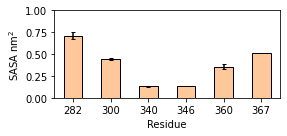

In [17]:
# plot
df = pd.read_csv('avg_SC_SASA_SER.csv')
df.plot(x='Residue',y='SASA (nm$^{2}$)',yerr= np.array(df['Error']),
       kind='bar',figsize = (4,2),legend=False,color = '#FEC89A',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=0)
plt.ylim(0,1)

plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SER_SASA_barplot.pdf')

In [16]:
residues = [286,297,313,317,326,330,338]
colors = ['blue','red','orange']
nsims=3

avg = []
err = []

for i in range(len(residues)):
    
    vals = []
    
    for s in range(1,nsims+1):
    
        dat = np.loadtxt(path+"sim{}/sasaTHR{}.xvg".format(s,residues[i]),skiprows=25)
    
        sasa = dat[:,2]
        time = dat[:,0]/1000 # convert to nanoseconds
        
        vals.append(np.mean(sasa)) 

    avg.append(np.mean(vals))
    err.append(np.std(vals)/np.sqrt(nsims))
    
df = pd.DataFrame()
df['Residue'] = residues
df['SASA (nm$^{2}$)'] = avg
df['Error'] = err

df.to_csv('avg_SC_SASA_THR.csv')
df

,Residue,SASA (nm$^{2}$),Error
0,286,0.237831,0.009328
1,297,0.729842,0.027666
2,313,0.624433,0.025945
3,317,0.663955,0.013776
4,326,0.545278,0.008500
5,330,0.695739,0.053358
6,338,0.211289,0.016665


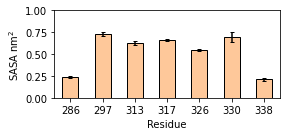

In [18]:
# plot
df = pd.read_csv('avg_SC_SASA_THR.csv')
df.plot(x='Residue',y='SASA (nm$^{2}$)',yerr= np.array(df['Error']),
       kind='bar',figsize = (4,2),legend=False,color = '#FEC89A',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=0)
plt.ylim(0,1)

plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('THR_SASA_barplot.pdf')

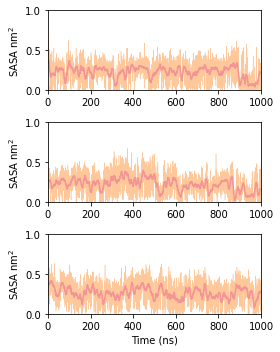

In [28]:
# individual simulation plots of the buried PTMs

site = 'THR286'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    dat = np.loadtxt(path+"sim{}/sasa{}.xvg".format(s,site),skiprows=25)[::10] # downsample 10k, 200 ps frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,1)
    plt.xlim(0,1000)

    if s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}.pdf'.format(site))

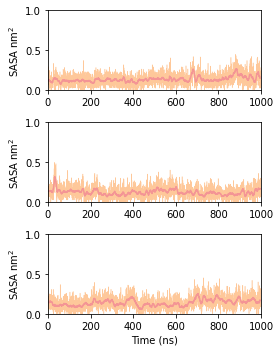

In [29]:
# individual simulation plots of the buried PTMs

site = 'SER340'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    dat = np.loadtxt(path+"sim{}/sasa{}.xvg".format(s,site),skiprows=25)[::10] # downsample 10k, 200 ps frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,1)
    plt.xlim(0,1000)

    if s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}.pdf'.format(site))

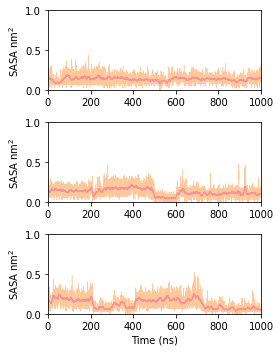

In [30]:
# individual simulation plots of the buried PTMs

site = 'SER346'
nsims=3
Nmov = 50

plt.figure(figsize= (4,5))

for s in range(1,nsims+1):
    
    plt.subplot(3,1,s)
    
    dat = np.loadtxt(path+"sim{}/sasa{}.xvg".format(s,site),skiprows=25)[::10] # downsample 10k, 200 ps frequency

    sasa = dat[:,2]
    time = dat[:,0]/1000 # convert to nanoseconds
    
    mov_x = np.convolve(time, np.ones(Nmov)/Nmov, mode='valid')
    mov_y = np.convolve(sasa, np.ones(Nmov)/Nmov, mode='valid')

    plt.plot(time,sasa,color = '#FEC89A',linewidth = 0.5)
    plt.plot(mov_x,mov_y,color = '#F49595',linewidth = 1.5)
    
    plt.ylim(0,1)
    plt.xlim(0,1000)

    if s==3:
        plt.xlabel('Time (ns)')
        plt.ylabel('SASA nm$^{2}$')
    else:
        plt.ylabel('SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('SASA_timecourses_{}.pdf'.format(site))